In [38]:
import numpy as np
import matplotlib.pyplot as plt
import json
import sys

sys.path.append('../src')

from config.config import PATHS

from patterns.alternations import PatternGenerator
from graphs.graph_creator import StrategyGraphBuilder
from graphs.best_graph_creator import GraphCreator
from graphs.cycle_analyzer import CycleAnalyzer
from graphs.graph_display import GraphVisualizer
from analysis.simulation import load_graph_data, simulate

### Define parameters

In [39]:
N = 9
s = 3
seed = 42
Numpat = 20
permute_columns = True # permute agents
permute_rows = False # permute time
rng = np.random.default_rng(seed)

### Create random patterns and graphs

In [40]:
gen = PatternGenerator(
    N=N,
    step=s,
    num_patterns=Numpat,
    permute_columns=permute_columns,
    permute_rows=permute_rows,
    rng=rng
)

gen.generate_many()

pattern_file = PATHS['patterns'] / 'patterns.json'
gen.save(pattern_file)

gb = StrategyGraphBuilder(rng)

gb.build_graphs()

ca = CycleAnalyzer(
    num_nodes=N,
    num_steps=s,
)

ca.process()

[{'0a': {'pattern': ['1', '0', '0'], 'neigh': ['4a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}}, '1a': {'pattern': ['0', '1', '0'], 'neigh': ['0a'], 'strat': {'1': '1', '0': '0'}, 'input freq': {'1': 1, '0': 2}}, '2a': {'pattern': ['0', '0', '1'], 'neigh': ['3a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}}, '3a': {'pattern': ['0', '1', '0'], 'neigh': ['5a'], 'strat': {'1': '1', '0': '0'}, 'input freq': {'1': 1, '0': 2}}, '4a': {'pattern': ['0', '0', '1'], 'neigh': ['6a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}}, '5a': {'pattern': ['1', '0', '0'], 'neigh': ['8a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}}, '6a': {'pattern': ['0', '1', '0'], 'neigh': ['5a'], 'strat': {'1': '1', '0': '0'}, 'input freq': {'1': 1, '0': 2}}, '7a': {'pattern': ['1', '0', '0'], 'neigh': ['4a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}}, '8a': {'pattern': ['0', '0', '1'], 'neigh': ['6a'], 'strat': {'0': '0'

### Create minumum diameter graph

In [41]:
graph = GraphCreator(N, s)
graph.build_graph()

output_path = graph.save_to_json()
print(f"Graph saved to: {output_path}")

ca = CycleAnalyzer(
    num_nodes=N,
    num_steps=s,
    sufix='_o'
)

ca.process()

Graph saved to: /home/carlos/Documents/InformationT/edgar_german/alternation_EFP/notebooks/../data/graphs/graph_data_N9s3_o.json
[{'0a': {'pattern': ['1', '0', '0'], 'neigh': ['6a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}, 'cycle': 0, 'ones in cycle': 1}, '1a': {'pattern': ['1', '0', '0'], 'neigh': ['6a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}, 'cycle': -1, 'ones in cycle': 0}, '2a': {'pattern': ['1', '0', '0'], 'neigh': ['6a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}, 'cycle': -1, 'ones in cycle': 0}, '3a': {'pattern': ['0', '1', '0'], 'neigh': ['0a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}, 'cycle': 0, 'ones in cycle': 1}, '4a': {'pattern': ['0', '1', '0'], 'neigh': ['0a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}, 'cycle': -1, 'ones in cycle': 0}, '5a': {'pattern': ['0', '1', '0'], 'neigh': ['0a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}, 'cycle': -1

### Plot graphs

In [42]:
# gv = GraphVisualizer(
#     num_nodes=N,
#     num_steps=s,
#     mode='pattern'
# )

# nets, output_files = gv.generate_all_patterns(width="600px", height="600px", physics=True)

# for i in range(len(nets)):
#     nets[i].show(str(output_files[i]), notebook=False)


# gv = GraphVisualizer(
#     num_nodes=N,
#     num_steps=s,
#     mode='pattern',
#     sufix='_o'
# )

# nets, output_files = gv.generate_all_patterns(width="600px", height="600px", physics=True)

# for i in range(len(nets)):
#     nets[i].show(str(output_files[i]), notebook=False)

### Classify by cycle size and diameter

In [43]:
def load_graph_data(n: int, s: int, sufix: str = '') -> dict:
    """
    Load graph data from a JSON file.
    
    Args:
        n: The first parameter for the filename
        s: The second parameter for the filename
        sufix: The suffix for the filename
        
    Returns:
        Dictionary containing the graph data
    """

    filename = f'graph_data_N{n:d}s{s:d}{sufix}.json'

    file_path = PATHS['graphs'] / filename
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

def classify_pattern(N, s):
    data = load_graph_data(N, s)
    data_o = load_graph_data(N, s, sufix='_o')
    diameters = {}
    for d in data:
        diameters[d['diameter']] = diameters.get(d['diameter'], 0) + 1
    diameters[data_o[0]['diameter']] = 1
    #print(diameters)
    for diam in diameters:
        l = []
        for d in data:
            if d['diameter'] == diam:
                l.append(d)
        for d in data_o:
            if d['diameter'] == diam:
                l.append(d)
        graph_file_path = PATHS['graphs'] / f'graph_data_N{N}s{s}_d{diam}.json'
        with open(graph_file_path, 'w') as json_file:
            json.dump(l, json_file)
    return diameters


In [44]:
diameters = classify_pattern(N,s)
diameters

{6: 7, 5: 9, 4: 2, -1: 1, 7: 1, 3: 1}

# Simulations

In [ ]:
# Compute the total payoff in a round for el farol bar problem, given N agents, B chairs and the current state
def compute_state_payoff(B, current_state):
    N = len(current_state)
    attendance = sum(1 for i in range(N) if current_state[i] == '1')
    if attendance <= B:
        return attendance  # All attendees get a payoff of 1
    else:
        return -attendance  # Only B attendees get a payoff of -1
    
# Find the period of the pattern
def find_pattern_period(series):
    first_p = series[-1]# data_o = load_graph_data(N, s, sufix='_o')
    # print(type(data))
    count = 1
    for p in range(len(series)-2, 0, -1):
        if series[p] != first_p:
            count += 1
        else:
            break
    return count

# Compute the inequality in a given pattern
def compute_inequality(series, i, T):
    window = series[i:i+T]
    t_window = np.array([list(s) for s in window]).T.astype(int)
    scores = np.sum(t_window, axis=1) / Tow to give chaos damage to weapons
    return float(np.sqrt(scores.var()))


    #print(down_agents)
    

In [46]:
procs = {i:1 for i in range(N)}
Neff = sum(procs.values())
steps = 30
agent_ids = [str(i) for i in procs.keys()]
#num_to_letter_map = dict(zip(range(0,26), string.ascii_lowercase))
#node_ids = [str(i)+num_to_letter_map[j] for i in procs.keys() for j in range(procs[i])]

all_series = {}
for d in diameters:
    se = []
    for n in range(diameters[d]):
        sufix = '_d'+str(d)
        series, ones = simulate(
            n=Neff, 
            s=s, 
            idx=n, 
            Nsteps=steps, 
            init_cond='0'*Neff,
            down_times=[0 for i in range(Neff)],
            down_lapses=[0 for i in range(Neff)], 
            down_agents=agent_ids, 
            random_thresh=0.5,
            seed=seed,
            sufix=sufix,
            print_info=False
        )
        se.append(series)
    all_series[d] = se

#all_series

In [47]:
all_payoffs = {}
all_inequalities = {}
for d in all_series:
    po = []
    inq = []
    for n in range(len(all_series[d])):
        series = all_series[d][n]
        T = find_pattern_period(series)
        #print(T)
        total_payoff = []
        inequality = []
        for i in range(0, len(series)-T):
            payoff = compute_state_payoff(s, series[i+T])
            ineq = compute_inequality(series, i, T)
            total_payoff.append(total_payoff[-1]+payoff if total_payoff else payoff)
            inequality.append(ineq)
        po.append(total_payoff)
        inq.append(inequality)
    all_payoffs[d] = po
    all_inequalities[d] = inq


In [48]:
av_payoffs = {}
av_inequalities = {}
for d in all_series:
    min_len = min(len(series) for series in all_payoffs[d])
    truncated_payoffs = [payoff[:min_len] for payoff in all_payoffs[d]]
    av_payoffs[d] = np.mean(truncated_payoffs, axis=0).tolist()
    truncated_inequalities = [inequality[:min_len] for inequality in all_inequalities[d]]
    av_inequalities[d] = np.mean(truncated_inequalities, axis=0).tolist()

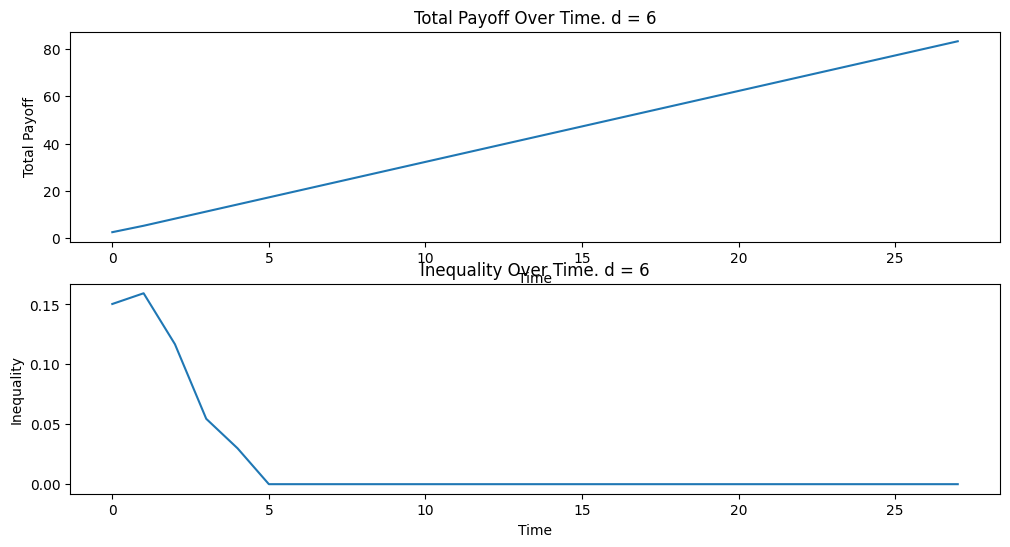

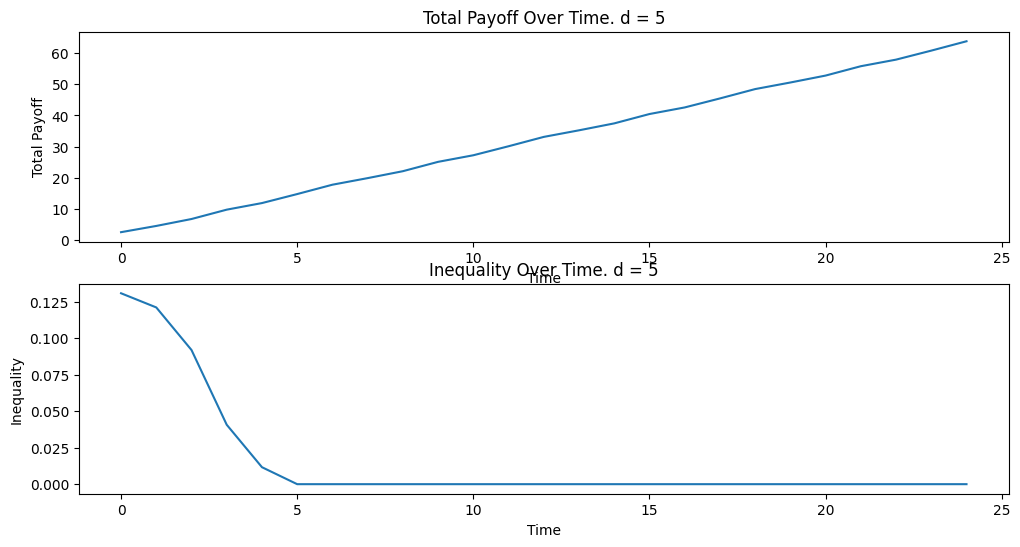

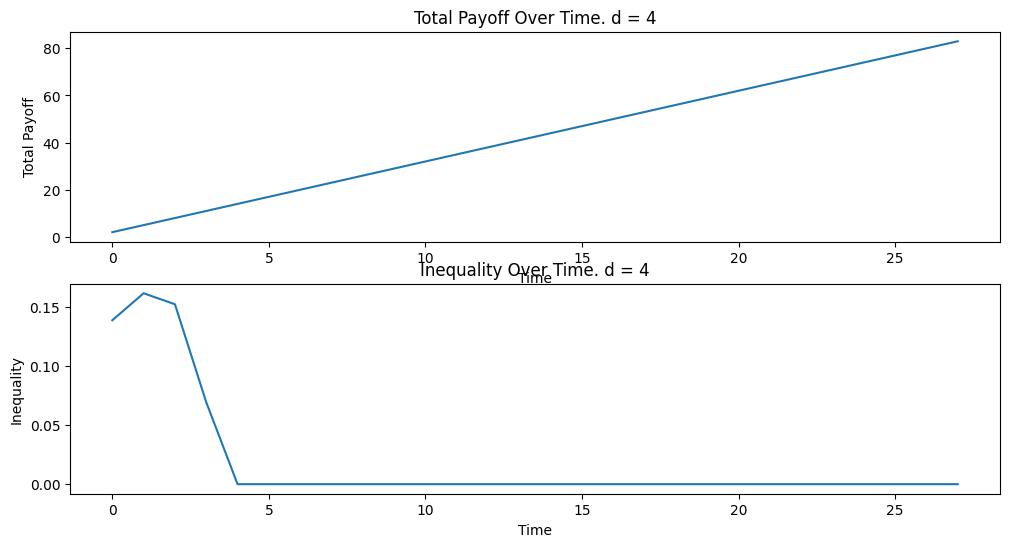

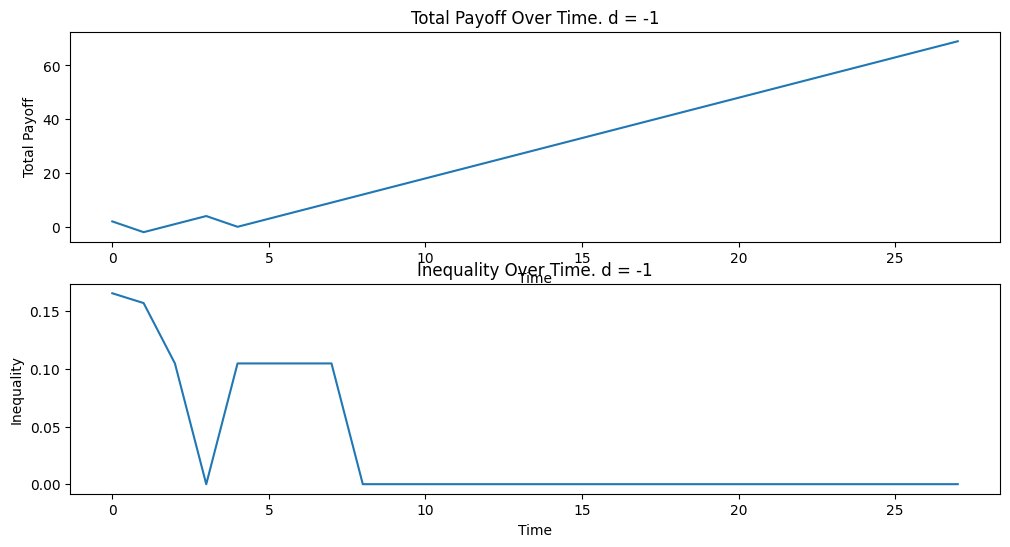

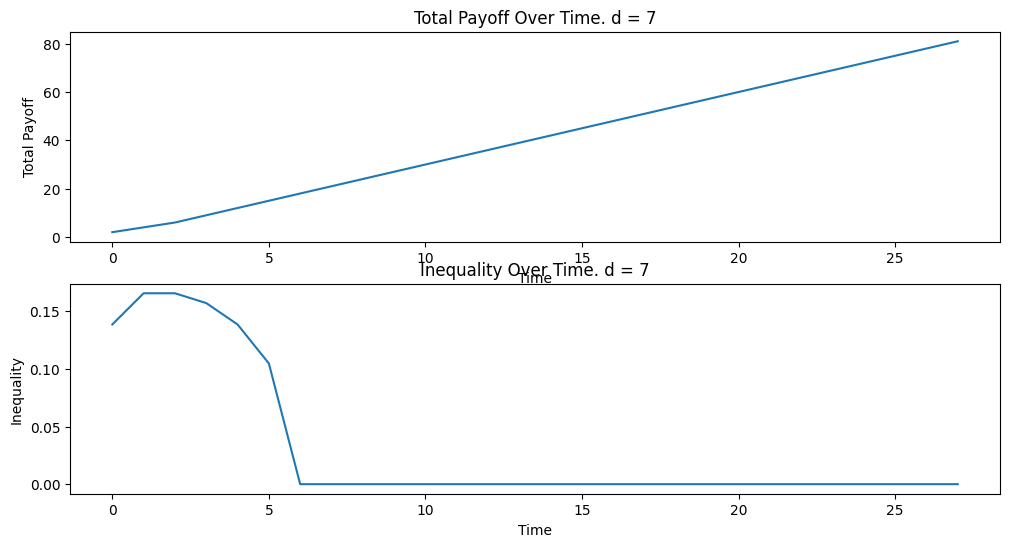

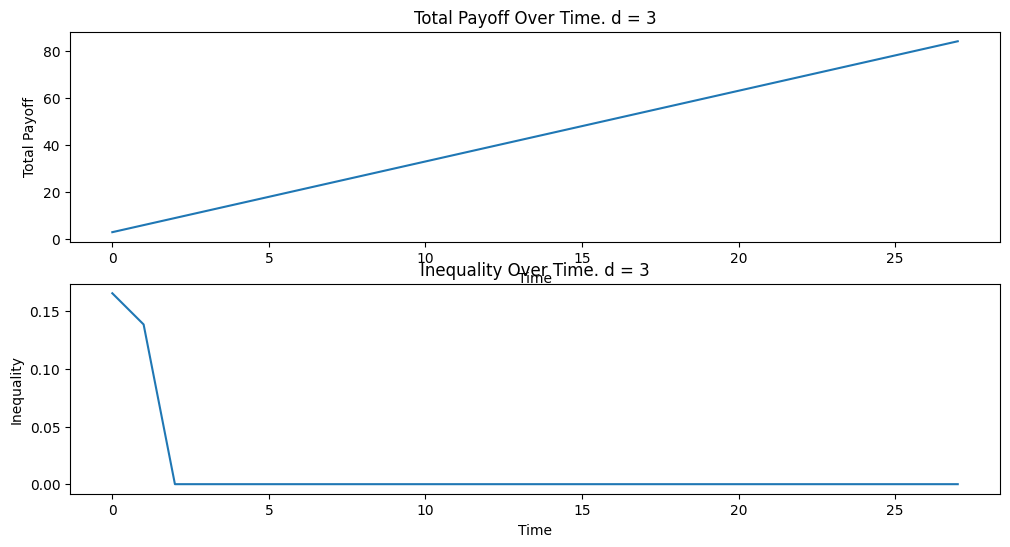

In [49]:
for d in all_series:
    t = np.arange(len(av_payoffs[d]))
    fig0 = plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(t, av_payoffs[d], label='Total Payoff')
    plt.xlabel('Time')
    plt.ylabel('Total Payoff')
    plt.title('Total Payoff Over Time. d = '+str(d))
    plt.subplot(2, 1, 2)
    plt.plot(t, av_inequalities[d], label='Inequality')
    plt.xlabel('Time')
    plt.ylabel('Inequality')
    plt.title('Inequality Over Time. d = '+str(d))